In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("PRSA_Data_Aotizhongxin_20130301-20170228.csv")

In [3]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [4]:
df.columns


Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [6]:
df.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

In [7]:
(df.isnull().sum() / len(df)) * 100

No         0.000000
year       0.000000
month      0.000000
day        0.000000
hour       0.000000
PM2.5      2.638033
PM10       2.047684
SO2        2.666553
NO2        2.917522
CO         5.065024
O3         4.902464
TEMP       0.057039
PRES       0.057039
DEWP       0.057039
RAIN       0.057039
wd         0.231006
WSPM       0.039927
station    0.000000
dtype: float64

In [8]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
})
missing.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
CO,1776,5.065024
O3,1719,4.902464
NO2,1023,2.917522
SO2,935,2.666553
PM2.5,925,2.638033
PM10,718,2.047684
wd,81,0.231006
RAIN,20,0.057039
DEWP,20,0.057039
PRES,20,0.057039


In [9]:
df.dtypes

No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

In [10]:
df_clean = df.copy()


In [11]:
df_clean = df_clean.dropna(subset=["PM2.5"])

In [12]:
numeric_cols = ["PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [13]:
df_clean["wd"] = df_clean["wd"].fillna(df_clean["wd"].mode()[0])

In [14]:
df_clean.isnull().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

In [15]:
df_clean.dtypes

No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

In [16]:
df_clean["station"].unique()

array(['Aotizhongxin'], dtype=object)

In [17]:
df_clean["station"].nunique()

1

In [18]:
df_encoded = pd.get_dummies(df_clean.drop(columns=["station"]), columns=["wd"], drop_first=True)

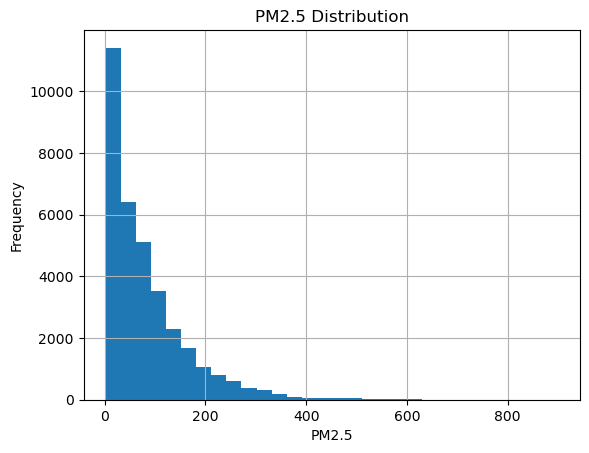

In [19]:
import matplotlib.pyplot as plt

df_clean["PM2.5"].hist(bins=30)
plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

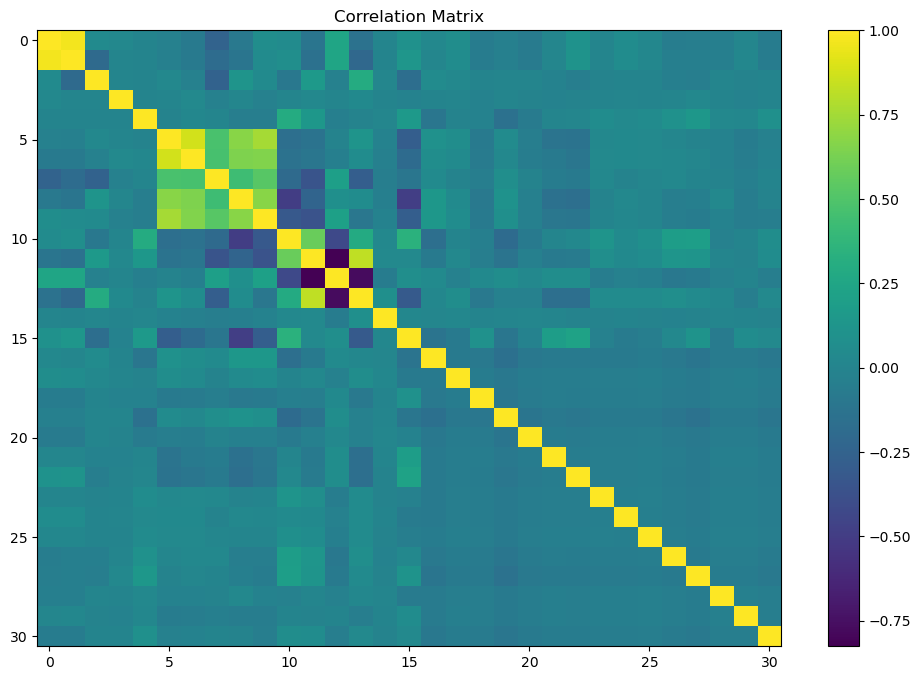

In [20]:
corr = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

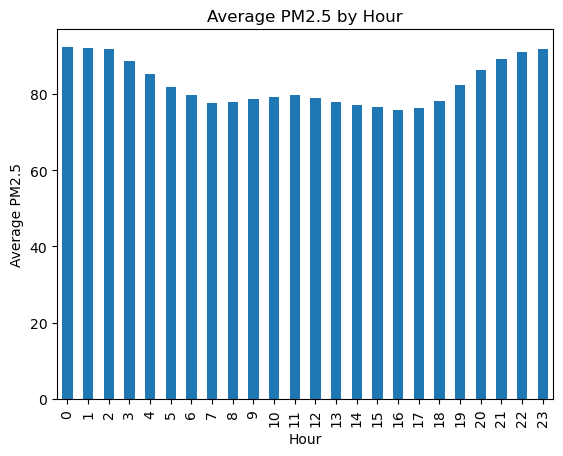

In [21]:
hourly_pm25 = df_clean.groupby("hour")["PM2.5"].mean()

hourly_pm25.plot(kind="bar")
plt.title("Average PM2.5 by Hour")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5")
plt.show()

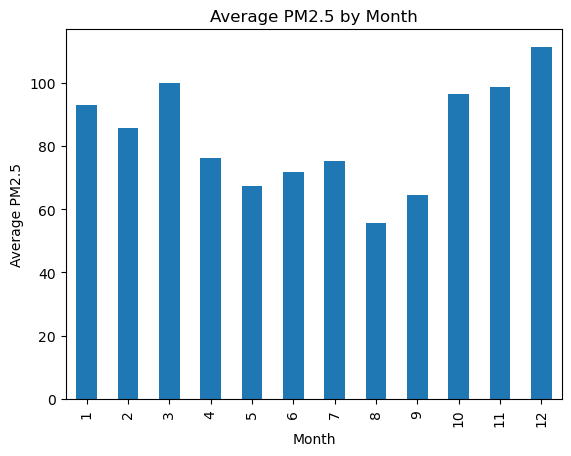

In [22]:
monthly_pm25 = df_clean.groupby("month")["PM2.5"].mean()

monthly_pm25.plot(kind="bar")
plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.show()

In [23]:
df_encoded.to_csv("pilot_clean_encoded.csv", index=False)

In [24]:
import os
import glob
import pandas as pd

files = glob.glob("*.csv")
df_all = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)

In [25]:
df_all.head()
df_all.info()
df_all["station"].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454907 entries, 0 to 454906
Data columns (total 33 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       454907 non-null  int64  
 1   year     454907 non-null  int64  
 2   month    454907 non-null  int64  
 3   day      454907 non-null  int64  
 4   hour     454907 non-null  int64  
 5   PM2.5    446168 non-null  float64
 6   PM10     448458 non-null  float64
 7   SO2      445886 non-null  float64
 8   NO2      442791 non-null  float64
 9   CO       434206 non-null  float64
 10  O3       441630 non-null  float64
 11  TEMP     454509 non-null  float64
 12  PRES     454514 non-null  float64
 13  DEWP     454504 non-null  float64
 14  RAIN     454517 non-null  float64
 15  WSPM     454589 non-null  float64
 16  wd_ENE   34139 non-null   object 
 17  wd_ESE   34139 non-null   object 
 18  wd_N     34139 non-null   object 
 19  wd_NE    34139 non-null   object 
 20  wd_NNE   34139 non-null   

12

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [27]:
df.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

In [28]:
import glob
import pandas as pd

In [29]:
files = glob.glob("*.csv")
files

['pilot_clean_encoded.csv',
 'PRSA_Data_Aotizhongxin_20130301-20170228.csv',
 'PRSA_Data_Changping_20130301-20170228.csv',
 'PRSA_Data_Dingling_20130301-20170228.csv',
 'PRSA_Data_Dongsi_20130301-20170228.csv',
 'PRSA_Data_Guanyuan_20130301-20170228.csv',
 'PRSA_Data_Gucheng_20130301-20170228.csv',
 'PRSA_Data_Huairou_20130301-20170228.csv',
 'PRSA_Data_Nongzhanguan_20130301-20170228.csv',
 'PRSA_Data_Shunyi_20130301-20170228.csv',
 'PRSA_Data_Tiantan_20130301-20170228.csv',
 'PRSA_Data_Wanliu_20130301-20170228.csv',
 'PRSA_Data_Wanshouxigong_20130301-20170228.csv']

In [30]:
df_all = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)

In [31]:
df_all.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW,wd,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,...,False,False,False,False,False,False,False,False,NaN,NaN
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,...,False,False,False,False,False,False,False,False,NaN,NaN
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,...,False,False,False,False,False,False,False,False,NaN,NaN
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,...,False,False,False,False,False,False,False,False,NaN,NaN
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,...,False,False,False,False,False,False,False,False,NaN,NaN


In [32]:
df_all["station"].nunique()

12

In [33]:
df_all.isnull().sum()

No              0
year            0
month           0
day             0
hour            0
PM2.5        8739
PM10         6449
SO2          9021
NO2         12116
CO          20701
O3          13277
TEMP          398
PRES          393
DEWP          403
RAIN          390
WSPM          318
wd_ENE     420768
wd_ESE     420768
wd_N       420768
wd_NE      420768
wd_NNE     420768
wd_NNW     420768
wd_NW      420768
wd_S       420768
wd_SE      420768
wd_SSE     420768
wd_SSW     420768
wd_SW      420768
wd_W       420768
wd_WNW     420768
wd_WSW     420768
wd          35961
station     34139
dtype: int64

In [34]:
files = glob.glob("PRSA_Data_*.csv")
files

['PRSA_Data_Aotizhongxin_20130301-20170228.csv',
 'PRSA_Data_Changping_20130301-20170228.csv',
 'PRSA_Data_Dingling_20130301-20170228.csv',
 'PRSA_Data_Dongsi_20130301-20170228.csv',
 'PRSA_Data_Guanyuan_20130301-20170228.csv',
 'PRSA_Data_Gucheng_20130301-20170228.csv',
 'PRSA_Data_Huairou_20130301-20170228.csv',
 'PRSA_Data_Nongzhanguan_20130301-20170228.csv',
 'PRSA_Data_Shunyi_20130301-20170228.csv',
 'PRSA_Data_Tiantan_20130301-20170228.csv',
 'PRSA_Data_Wanliu_20130301-20170228.csv',
 'PRSA_Data_Wanshouxigong_20130301-20170228.csv']

In [35]:
df_all = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)

In [36]:
len(files)

12

In [37]:
df_all = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)

In [38]:
df_all.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [39]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [40]:
df_all["station"].nunique()

12

In [41]:
df_all.isnull().sum()

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

In [42]:
missing_all = pd.DataFrame({
    "missing_count": df_all.isnull().sum(),
    "missing_percent": (df_all.isnull().sum() / len(df_all)) * 100
})
missing_all.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
CO,20701,4.919813
O3,13277,3.155421
NO2,12116,2.879497
SO2,9021,2.143937
PM2.5,8739,2.076916
PM10,6449,1.532674
wd,1822,0.433018
DEWP,403,0.095777
TEMP,398,0.094589
PRES,393,0.093401


In [43]:
df_all_clean = df_all.copy()

In [44]:
df_all_clean = df_all_clean.dropna(subset=["PM2.5"])

In [45]:
numeric_cols = ["PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

for col in numeric_cols:
    df_all_clean[col] = df_all_clean[col].fillna(df_all_clean[col].median())

In [46]:
df_all_clean["wd"] = df_all_clean["wd"].fillna(df_all_clean["wd"].mode()[0])

In [47]:
df_all_clean.isnull().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

In [48]:
df_all_encoded = pd.get_dummies(df_all_clean, columns=["wd", "station"], drop_first=True)

In [49]:
df_all_encoded.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,...,False,False,False,False,False,False,False,False,False,False
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,...,False,False,False,False,False,False,False,False,False,False
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,...,False,False,False,False,False,False,False,False,False,False
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,...,False,False,False,False,False,False,False,False,False,False
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,...,False,False,False,False,False,False,False,False,False,False


In [50]:
df_all_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412029 entries, 0 to 420767
Data columns (total 42 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   No                     412029 non-null  int64  
 1   year                   412029 non-null  int64  
 2   month                  412029 non-null  int64  
 3   day                    412029 non-null  int64  
 4   hour                   412029 non-null  int64  
 5   PM2.5                  412029 non-null  float64
 6   PM10                   412029 non-null  float64
 7   SO2                    412029 non-null  float64
 8   NO2                    412029 non-null  float64
 9   CO                     412029 non-null  float64
 10  O3                     412029 non-null  float64
 11  TEMP                   412029 non-null  float64
 12  PRES                   412029 non-null  float64
 13  DEWP                   412029 non-null  float64
 14  RAIN                   412029 non-null  f

In [51]:
df_all_encoded.to_csv("air_quality_all_clean_encoded.csv", index=False)

In [52]:
df_all["station"].nunique()

12

In [53]:
missing_all = pd.DataFrame({
    "missing_count": df_all.isnull().sum(),
    "missing_percent": (df_all.isnull().sum() / len(df_all)) * 100
})
missing_all.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
CO,20701,4.919813
O3,13277,3.155421
NO2,12116,2.879497
SO2,9021,2.143937
PM2.5,8739,2.076916
PM10,6449,1.532674
wd,1822,0.433018
DEWP,403,0.095777
TEMP,398,0.094589
PRES,393,0.093401


In [54]:
df_all_clean = df_all_clean.dropna(subset=["PM2.5"])

In [55]:
numeric_cols = ["PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

for col in numeric_cols:
    df_all_clean[col] = df_all_clean[col].fillna(df_all_clean[col].median())

In [56]:
df_all_clean["wd"] = df_all_clean["wd"].fillna(df_all_clean["wd"].mode()[0])

In [57]:
df_all_clean.isnull().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

In [58]:
df_all_clean.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

In [59]:
df_all_clean = df_all_clean.drop(columns=["No"])

In [60]:
df_all_encoded = pd.get_dummies(df_all_clean, columns=["wd", "station"], drop_first=True)

In [61]:
df_all_encoded.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,...,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,...,False,False,False,False,False,False,False,False,False,False
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,...,False,False,False,False,False,False,False,False,False,False
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,...,False,False,False,False,False,False,False,False,False,False
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,...,False,False,False,False,False,False,False,False,False,False
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,...,False,False,False,False,False,False,False,False,False,False


In [62]:
df_all_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412029 entries, 0 to 420767
Data columns (total 41 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   year                   412029 non-null  int64  
 1   month                  412029 non-null  int64  
 2   day                    412029 non-null  int64  
 3   hour                   412029 non-null  int64  
 4   PM2.5                  412029 non-null  float64
 5   PM10                   412029 non-null  float64
 6   SO2                    412029 non-null  float64
 7   NO2                    412029 non-null  float64
 8   CO                     412029 non-null  float64
 9   O3                     412029 non-null  float64
 10  TEMP                   412029 non-null  float64
 11  PRES                   412029 non-null  float64
 12  DEWP                   412029 non-null  float64
 13  RAIN                   412029 non-null  float64
 14  WSPM                   412029 non-null  f

In [63]:
df_all_encoded.to_csv("air_quality_all_clean_encoded.csv", index=False)

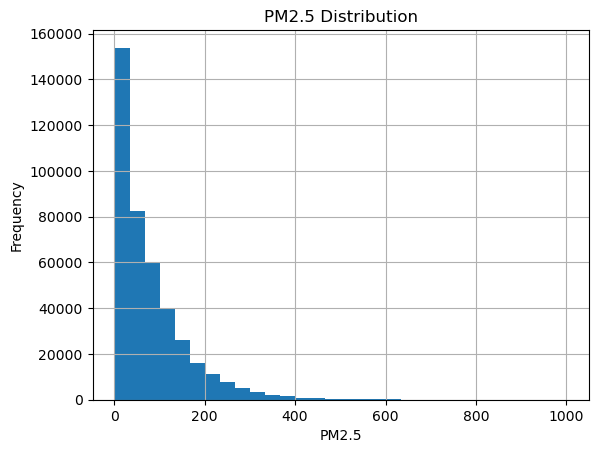

In [71]:
import matplotlib.pyplot as plt

df_all_clean["PM2.5"].hist(bins=30)
plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.savefig("pm25_distribution.png", bbox_inches="tight")
plt.show()

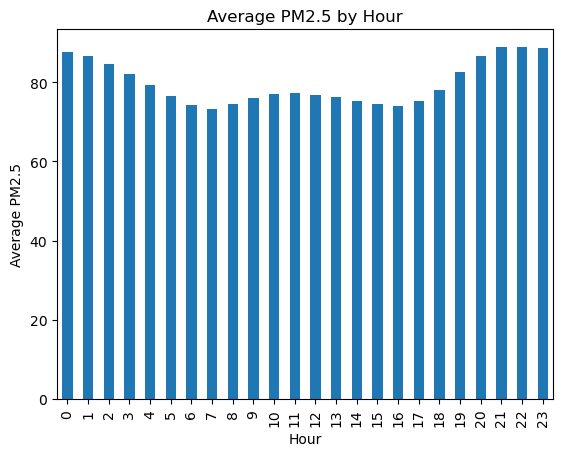

In [72]:
hourly_pm25 = df_all_clean.groupby("hour")["PM2.5"].mean()

hourly_pm25.plot(kind="bar")
plt.title("Average PM2.5 by Hour")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5")
plt.savefig("hourly_pm25.png", bbox_inches="tight")
plt.show()

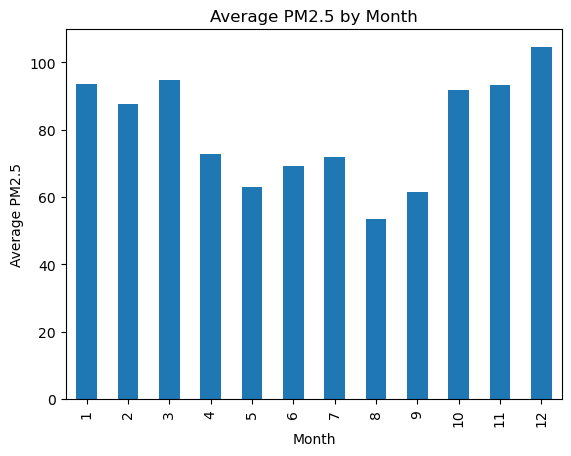

In [73]:
monthly_pm25 = df_all_clean.groupby("month")["PM2.5"].mean()

monthly_pm25.plot(kind="bar")
plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.savefig("monthly_pm25.png", bbox_inches="tight")
plt.show()

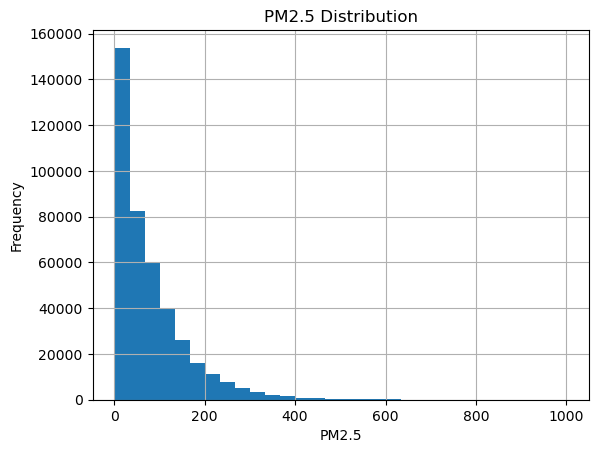

In [67]:
import matplotlib.pyplot as plt

df_all_clean["PM2.5"].hist(bins=30)
plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

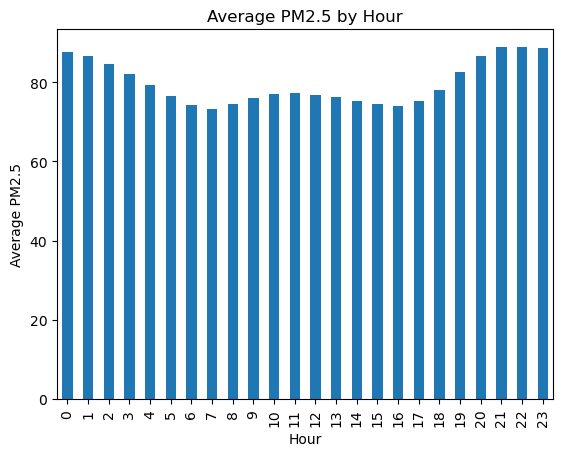

In [68]:
hourly_pm25 = df_all_clean.groupby("hour")["PM2.5"].mean()

hourly_pm25.plot(kind="bar")
plt.title("Average PM2.5 by Hour")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5")
plt.show()

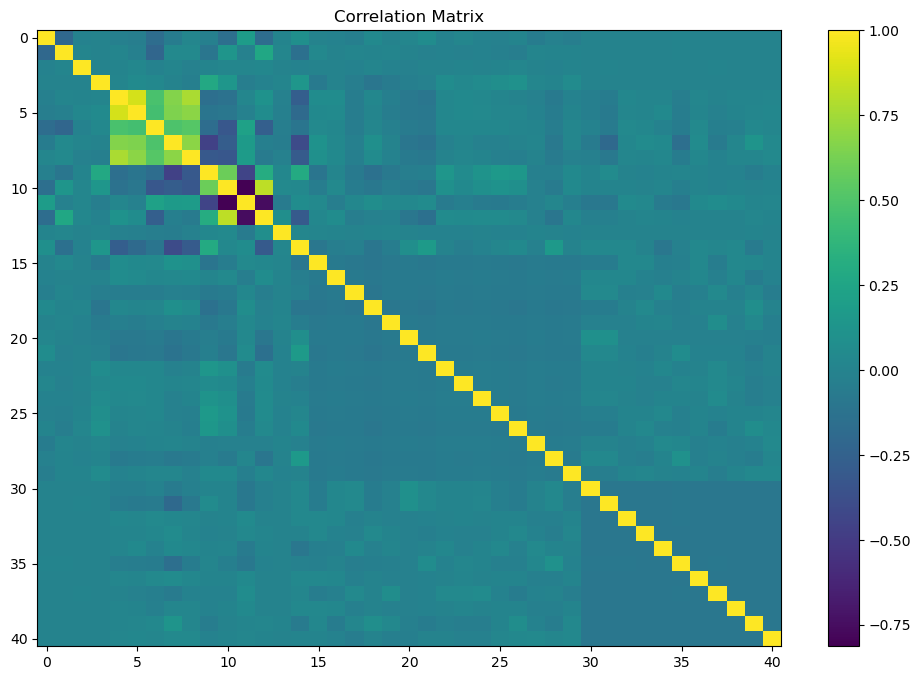

In [74]:
corr = df_all_encoded.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png", bbox_inches="tight")
plt.show()

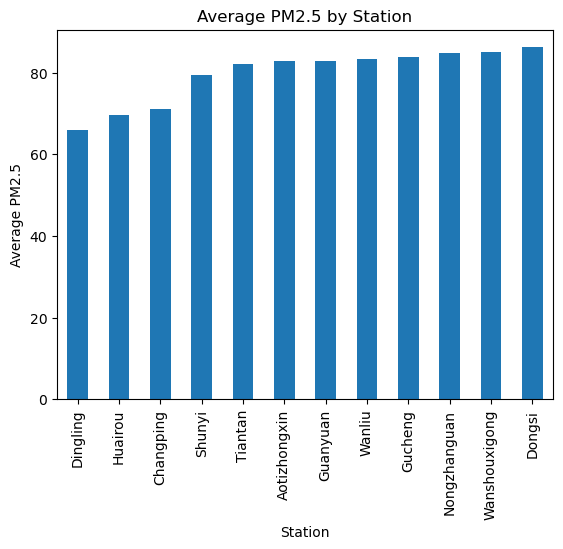

In [75]:
station_pm25 = df_all_clean.groupby("station")["PM2.5"].mean().sort_values()

station_pm25.plot(kind="bar")
plt.title("Average PM2.5 by Station")
plt.xlabel("Station")
plt.ylabel("Average PM2.5")
plt.savefig("station_pm25.png", bbox_inches="tight")
plt.show()

In [76]:
corr = df_all_encoded.corr(numeric_only=True)
corr["PM2.5"].sort_values(ascending=False)

PM2.5                    1.000000
PM10                     0.882394
CO                       0.769780
NO2                      0.660523
SO2                      0.479821
DEWP                     0.114625
wd_ESE                   0.067903
wd_ENE                   0.066418
wd_SE                    0.046428
wd_SSE                   0.035508
wd_NE                    0.029459
wd_S                     0.025928
station_Dongsi           0.023870
station_Wanshouxigong    0.019523
station_Nongzhanguan     0.018851
PRES                     0.018562
station_Gucheng          0.015161
station_Wanliu           0.013434
wd_SSW                   0.012237
station_Guanyuan         0.011735
hour                     0.011709
month                    0.010438
station_Tiantan          0.008854
day                      0.003428
station_Shunyi          -0.001123
wd_SW                   -0.001571
wd_WSW                  -0.006873
RAIN                    -0.014354
wd_W                    -0.015813
year          